In [1]:
!pip install tensorflow opencv-python scikit-learn matplotlib pandas numpy pillow

Step 1 & Step 2: Dataset Selection, Sampling, and Splitting

In [2]:
import os
import tensorflow as tf

BASE_DIR = "/kaggle/input/datasets/fahimahamed20301393/shom-dataset/Shom/real_vs_fake/real-vs-fake"
train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir = os.path.join(BASE_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load a safe subset of the dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary"
).take(200)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary"
).take(50)

# --- এখানে .shuffle() যোগ করা হয়েছে যাতে উভয় ক্লাসের (Real & Fake) ডাটা মিক্স থাকে ---
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False
).shuffle(buffer_size=10000, seed=42).take(50)

print("Dataset successfully loaded with a reduced subset and proper shuffling!")

Found 100000 files belonging to 2 classes.


I0000 00:00:1788938801.634934      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788938801.638063      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Dataset successfully loaded with a reduced subset and proper shuffling!


Step 3: Image Preparation & Three Representations (RGB, ELA, SRM)

In [3]:
import numpy as np
from PIL import Image, ImageChops
import cv2

def generate_ela(image_path, quality=90):
    """Generate Error Level Analysis (ELA) image representation."""
    original = Image.open(image_path).convert('RGB')
    temp_path = "temp_ela.jpg"
    original.save(temp_path, 'JPEG', quality=quality)
    resaved = Image.open(temp_path)
    
    ela_image = ImageChops.difference(original, resaved)
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    ela_image = Image.eval(ela_image, lambda x: min(int(x * scale), 255))
    if os.path.exists(temp_path):
        os.remove(temp_path)
    return ela_image

def generate_srm(image_path):
    """Generate Spatial Rich Model (SRM) filtered noise representation."""
    img = cv2.imread(image_path)
    if img is None:
        img = np.zeros((224, 224, 3), dtype=np.uint8)
    img = cv2.resize(img, (224, 224))
    
    kernel = np.array([
        [-1,  2, -1],
        [ 2, -4,  2],
        [-1,  2, -1]
    ], dtype=np.float32)
    
    srm_img = cv2.filter2D(img, -1, kernel)
    srm_img = cv2.normalize(srm_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    return Image.fromarray(np.uint8(srm_img))

print("ELA and SRM functions are ready!")

ELA and SRM functions are ready!


Selected sample image: /kaggle/input/datasets/fahimahamed20301393/shom-dataset/Shom/real_vs_fake/real-vs-fake/train/fake/9D3LAS4ZJJ.jpg


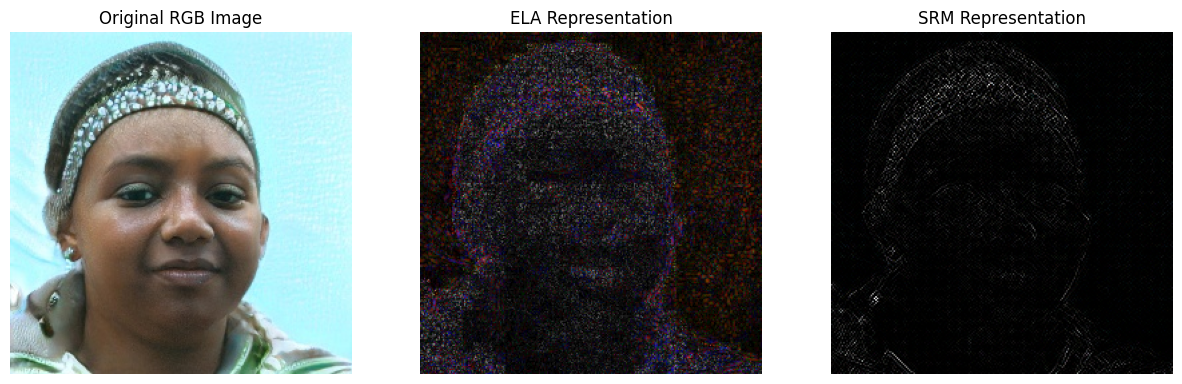

In [4]:
import matplotlib.pyplot as plt
import random

# Pick a random sample image from your training directory
train_classes = os.listdir(train_dir)
random_class = random.choice(train_classes)
class_path = os.path.join(train_dir, random_class)
random_image_name = random.choice(os.listdir(class_path))
sample_image_path = os.path.join(class_path, random_image_name)

print(f"Selected sample image: {sample_image_path}")

# Generate representations
ela_img = generate_ela(sample_image_path)
srm_img = generate_srm(sample_image_path)
original_img = Image.open(sample_image_path).convert('RGB')

# Plot and display side-by-side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(ela_img)
plt.title("ELA Representation")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(srm_img)
plt.title("SRM Representation")
plt.axis('off')

plt.show()

Step 4: Model TrainingThree separate MobileNetV2 models are trained (one each for RGB, ELA, and SRM).  Training settings: Adam optimizer, learning rate 0.0001, batch size 32, maximum 30 epochs, and early stopping patience of 5 epochs. Experiments use 3 fixed random seeds to average performance variations

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_mobilenetv2_model():
    """Build MobileNetV2 model configured for binary classification."""
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)  # Real (0) or Fake (1)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),  # Paper specified learning rate
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Model builder function is ready!")

Model builder function is ready!


Single Model Training with Safe Seeding

In [6]:



# import random
# import numpy as np
# from tensorflow.keras.callbacks import EarlyStopping

# import random
# import numpy as np
# import tensorflow as tf

# def set_global_seed(seed):
#     """Safely set random seeds for reproducibility."""
#     random.seed(seed)
#     np.random.seed(seed)
#     tf.random.set_seed(seed)

# def train_single_model_full_epochs(train_ds, valid_ds, seed=42, representation_name="RGB"):
#     print(f"\n--- Training {representation_name} Model for Full 30 Epochs ---")
#     set_global_seed(seed)
    
#     model = build_mobilenetv2_model()
    
#     # EarlyStopping is removed (callbacks=[]) so it runs all 30 epochs strictly
#     history = model.fit(
#         train_ds,
#         validation_data=valid_ds,
#         epochs=30,  # Runs all 30 epochs completely
#         callbacks=[] 
#     )
#     return model, history

# print("Training function is ready!")

# # Train using a single seed for the full 30 epochs
# rgb_model, rgb_history = train_single_model_full_epochs(train_dataset, valid_dataset, seed=42, representation_name="RGB")

# print("Training finished successfully for all 30 epochs!")

--- Training MobileNetV2 (RGB) ---

--- Training RGB Model for Full 30 Epochs ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30


2026-09-09 07:27:53.891493: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 07:27:54.028824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788938892.736656      81 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 87s 131ms/step - accuracy: 0.8313 - loss: 0.3655 - val_accuracy: 0.5362 - val_loss: 1.5744
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.9737 - loss: 0.0772 - val_accuracy: 0.6944 - val_loss: 1.1294
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9875 - loss: 0.0391 - val_accuracy: 0.8500 - val_loss: 0.4828
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9875 - loss: 0.0327 - val_accuracy: 0.8531 - val_loss: 0.4729
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.8650 - val_loss: 0.5529
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9934 - loss: 0.0179 - val_accuracy: 0.7144 - val_loss: 1.8790
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9936 - loss: 0.0182 - val_accuracy: 0.7725 - val_loss: 1.2784
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9909 - loss: 0.0239 - val

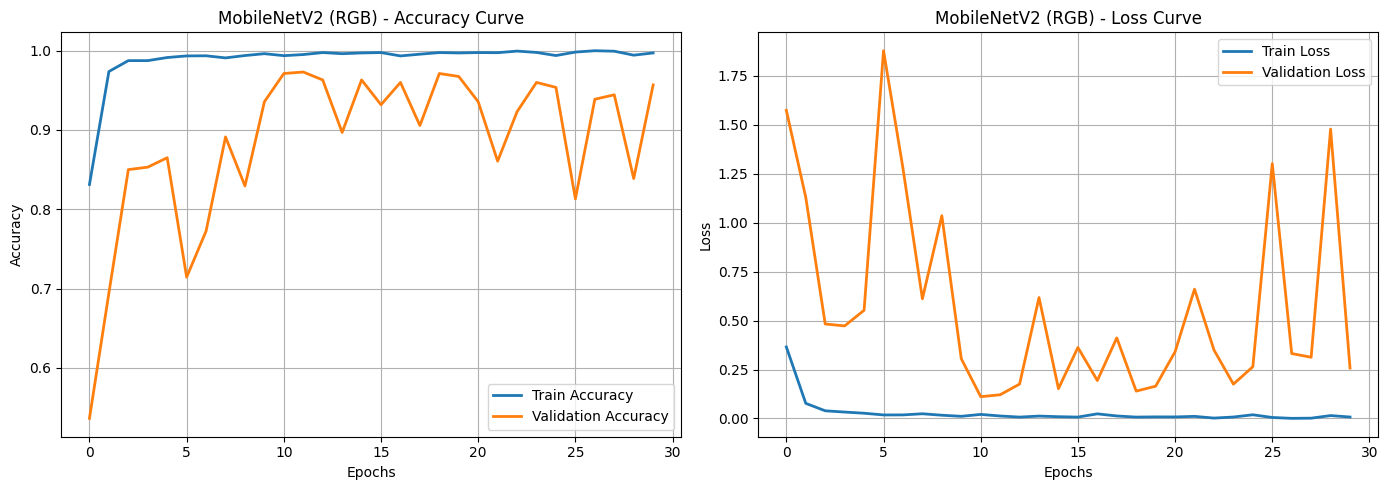

✅ RGB Training & Plotting Done Successfully!


In [7]:
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def set_global_seed(seed):
  """Safely set random seeds for reproducibility."""
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)


def train_single_model_full_epochs(
    train_ds, valid_ds, seed=42, representation_name="RGB"
):
  print(f"\n--- Training {representation_name} Model for Full 30 Epochs ---")
  set_global_seed(seed)

  model = build_mobilenetv2_model()

  history = model.fit(
      train_ds, validation_data=valid_ds, epochs=30, callbacks=[]
  )
  return model, history


def plot_training_history(history, model_title="Model"):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  # Accuracy Graph
  ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
  ax1.plot(
      history.history['val_accuracy'], label='Validation Accuracy', linewidth=2
  )
  ax1.set_title(f'{model_title} - Accuracy Curve')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Accuracy')
  ax1.legend()
  ax1.grid(True)

  # Loss Graph
  ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
  ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
  ax2.set_title(f'{model_title} - Loss Curve')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Loss')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()


# ==========================================
# RGB Model Training & Plotting (Ek cell-e shob)
# ==========================================
print('--- Training MobileNetV2 (RGB) ---')
rgb_model, rgb_history = train_single_model_full_epochs(
    train_dataset, valid_dataset, seed=42, representation_name='RGB'
)

plot_training_history(rgb_history, model_title='MobileNetV2 (RGB)')
print('✅ RGB Training & Plotting Done Successfully!')


--- Training MobileNetV2 (ELA) ---

--- Training ELA Model for Full 30 Epochs ---
Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 129ms/step - accuracy: 0.8305 - loss: 0.3698 - val_accuracy: 0.5344 - val_loss: 1.4622
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9700 - loss: 0.0823 - val_accuracy: 0.6719 - val_loss: 1.1341
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9862 - loss: 0.0409 - val_accuracy: 0.7831 - val_loss: 0.8291
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9917 - loss: 0.0264 - val_accuracy: 0.9081 - val_loss: 0.3635
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9919 - loss: 0.0250 - val_accuracy: 0.8675 - val_loss: 0.5341
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9919 - loss: 0.0218 - val_accuracy: 0.8950 - val_loss: 0.4287
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9928 - loss: 0.0217 - val_accuracy: 0.9475 - val_loss: 0.1944


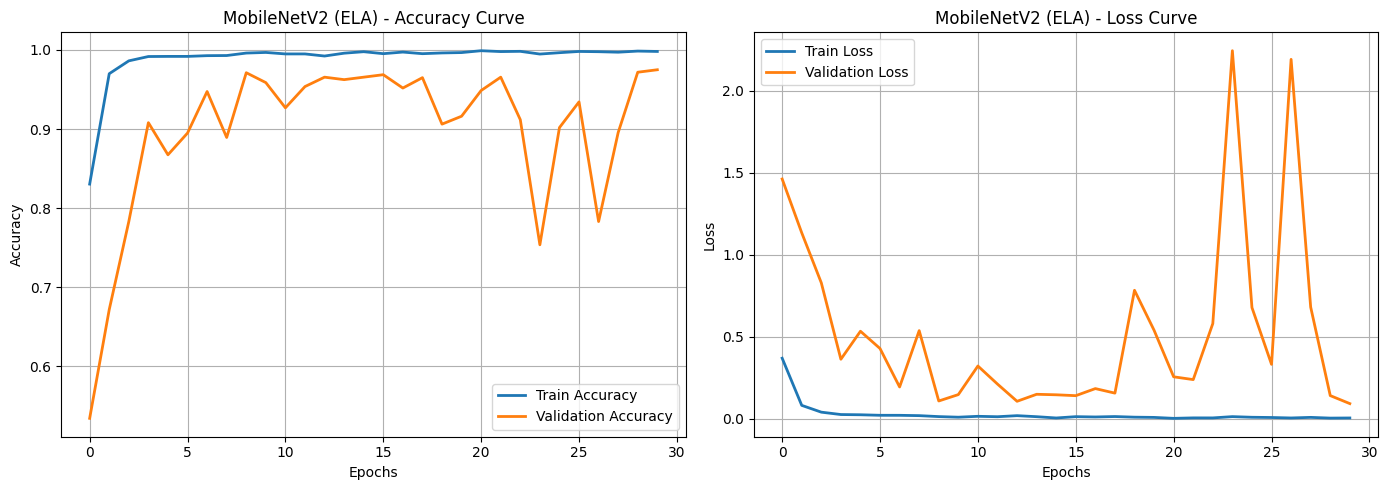


✅ All models trained and histories plotted successfully!


In [8]:
import matplotlib.pyplot as plt


# 1. Training history plot korar function (Shudhu ekbar define korlei hobe)
def plot_training_history(history, model_title="Model"):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  # Accuracy Graph
  ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
  ax1.plot(
      history.history['val_accuracy'], label='Validation Accuracy', linewidth=2
  )
  ax1.set_title(f'{model_title} - Accuracy Curve')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Accuracy')
  ax1.legend()
  ax1.grid(True)

  # Loss Graph
  ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
  ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
  ax2.set_title(f'{model_title} - Loss Curve')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Loss')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

  # --- 4. RGB Model Train & Plot ---
print('\n--- Training MobileNetV2 (ELA) ---')
ela_model, ela_history = train_single_model_full_epochs(
    train_dataset,  # Jodi ELA er jonno alada dataset thake, seta hobe
    valid_dataset,
    seed=42,
    representation_name='ELA',
)
plot_training_history(ela_history, model_title='MobileNetV2 (ELA)')
print('\n✅ All models trained and histories plotted successfully!')  

Run Training

--- Training MobileNetV2 (SRM) ---

--- Training SRM Model for Full 30 Epochs ---
Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 129ms/step - accuracy: 0.8170 - loss: 0.3750 - val_accuracy: 0.5031 - val_loss: 2.6967
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9759 - loss: 0.0729 - val_accuracy: 0.5981 - val_loss: 1.9705
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.7119 - val_loss: 1.4368
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9928 - loss: 0.0216 - val_accuracy: 0.8356 - val_loss: 0.7526
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9866 - loss: 0.0360 - val_accuracy: 0.8969 - val_loss: 0.3583
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9898 - loss: 0.0296 - val_accuracy: 0.8712 - val_loss: 0.5253
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9914 - loss: 0.0220 - val_accuracy: 0.9463 - val_loss: 0.2011
E

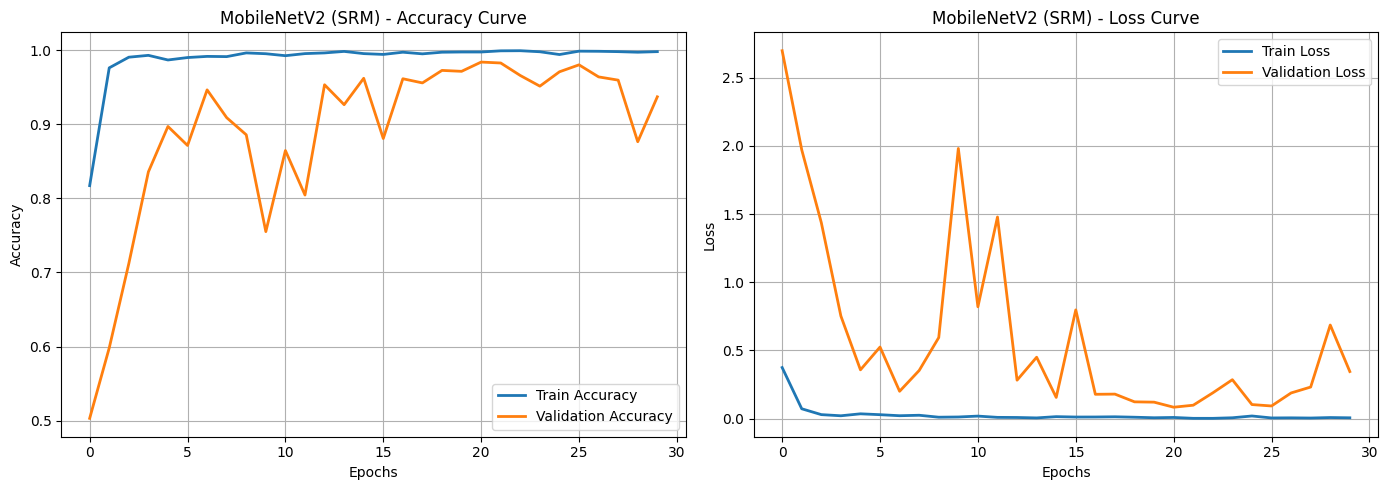

In [9]:
import matplotlib.pyplot as plt


# 1. Training history plot korar function (Shudhu ekbar define korlei hobe)
def plot_training_history(history, model_title="Model"):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  # Accuracy Graph
  ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
  ax1.plot(
      history.history['val_accuracy'], label='Validation Accuracy', linewidth=2
  )
  ax1.set_title(f'{model_title} - Accuracy Curve')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Accuracy')
  ax1.legend()
  ax1.grid(True)

  # Loss Graph
  ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
  ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
  ax2.set_title(f'{model_title} - Loss Curve')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Loss')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

  # --- 4. RGB Model Train & Plot ---
print('--- Training MobileNetV2 (SRM) ---')
srm_model, srm_history = train_single_model_full_epochs(
    train_dataset,  # Jodi SRM er jonno alada dataset thake, seta hobe
    valid_dataset,
    seed=42,
    representation_name='SRM',
)
plot_training_history(srm_history, model_title='MobileNetV2 (SRM)')

Step 5: Performance Evaluation
Evaluates model efficacy using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrices

In [10]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_fscore_support
import numpy as np
import tensorflow as tf

def evaluate_model(model, test_ds, representation_name):
    """Evaluate performance metrics on the test dataset without order mismatch."""
    y_pred_probs_list = []
    y_true_list = []
    
    # Loop through the dataset once to collect predictions and labels in sync
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_pred_probs_list.append(preds)
        y_true_list.append(y.numpy())
        
    y_pred_probs = np.concatenate(y_pred_probs_list, axis=0)
    y_true = np.concatenate(y_true_list, axis=0).ravel()
    
    y_pred = (y_pred_probs > 0.5).astype(int).ravel()

    acc = np.mean(y_pred == y_true)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    
    try:
        roc_auc = roc_auc_score(y_true, y_pred_probs)
    except:
        roc_auc = 0.0
        
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- {representation_name} Performance Metrics ---")
    print(f"Accuracy    : {acc * 100:.2f}%")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1-score    : {f1:.4f}")
    print(f"ROC-AUC     : {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    return acc, precision, recall, f1, roc_auc, cm

 
 
evaluation_configs = [
    (rgb_model, test_dataset, "RGB"),   # RGB  
    (ela_model, test_dataset, "ELA"),   # ELA  
    (srm_model, test_dataset, "SRM")    # SRM  
]

all_results = {}

 
for model, test_ds, name in evaluation_configs:
    if model is not None and test_ds is not None:
        acc, prec, rec, f1, auc, cm = evaluate_model(model, test_ds, name)
        all_results[name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'AUC': auc,
            'Confusion_Matrix': cm
        }
    else:
        print(f"\n--- Warning: {name} model is not defined! ---")

print("\nAll models evaluation finished successfully!")

print("\nAll models evaluation finished successfully!")


--- RGB Performance Metrics ---
Accuracy    : 96.75%
Precision   : 0.9528
Recall      : 0.9911
F1-score    : 0.9716
ROC-AUC     : 0.9958
Confusion Matrix:
[[660  44]
 [  8 888]]

--- ELA Performance Metrics ---
Accuracy    : 97.19%
Precision   : 0.9863
Recall      : 0.9632
F1-score    : 0.9746
ROC-AUC     : 0.9974
Confusion Matrix:
[[692  12]
 [ 33 863]]

--- SRM Performance Metrics ---
Accuracy    : 94.81%
Precision   : 0.9196
Recall      : 0.9978
F1-score    : 0.9571
ROC-AUC     : 0.9955
Confusion Matrix:
[[591  81]
 [  2 926]]

All models evaluation finished successfully!

All models evaluation finished successfully!



--- Starting Evaluation for RGB ---
Processed 10 batches...
Processed 20 batches...
Processed 30 batches...
Processed 40 batches...
Processed 50 batches...

--- RGB Classification Report ---
              precision    recall  f1-score   support

        Real       1.00      0.93      0.96       704
        Fake       0.94      1.00      0.97       896

    accuracy                           0.97      1600
   macro avg       0.97      0.96      0.96      1600
weighted avg       0.97      0.97      0.97      1600

ROC-AUC Score: 0.9982


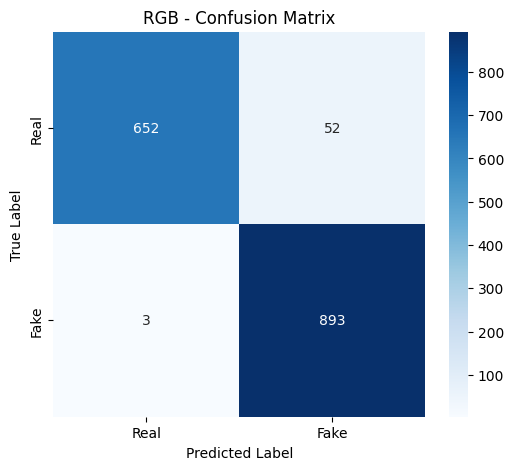

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model_safely(model, test_dataset, representation_name="Model"):
    print(f"\n--- Starting Evaluation for {representation_name} ---")
    
    y_pred_probs_list = []
    y_true_list = []
    
    # সিঙ্গেল লুপে প্রেডিকশন এবং লেবেল সংগ্রহ (হ্যাং হওয়া রোধ করতে ব্যাচ কাউন্ট প্রিন্ট হবে)
    for i, (x, y) in enumerate(test_dataset):
        preds = model.predict(x, verbose=0)
        y_pred_probs_list.append(preds)
        
        if hasattr(y, 'numpy'):
            y_true_list.append(y.numpy())
        else:
            y_true_list.append(np.array(y))
            
        # প্রতি ১০টি ব্যাচ পর পর প্রিন্ট করবে যাতে বোঝা যায় কোড রান হচ্ছে
        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1} batches...")
            
    y_pred_probs = np.concatenate(y_pred_probs_list, axis=0)
    y_true = np.concatenate(y_true_list, axis=0).ravel()
    
    y_pred = (y_pred_probs > 0.5).astype(int).ravel()
    y_pred_probs = y_pred_probs.ravel()

    # ক্লাসিফিকেশন রিপোর্ট
    print(f"\n--- {representation_name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], zero_division=0))

    # ROC-AUC স্কোর
    try:
        auc_score = roc_auc_score(y_true, y_pred_probs)
    except Exception as e:
        auc_score = 0.0
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{representation_name} - Confusion Matrix')
    plt.show()

# --- এভাবে রান করবেন ---
evaluate_model_safely(rgb_model, test_dataset, representation_name="RGB")


--- Starting Evaluation for ELA ---
Processed 10 batches...
Processed 20 batches...
Processed 30 batches...
Processed 40 batches...
Processed 50 batches...

--- ELA Classification Report ---
              precision    recall  f1-score   support

        Real       0.98      0.98      0.98       992
        Fake       0.97      0.97      0.97       608

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600

ROC-AUC Score: 0.9972


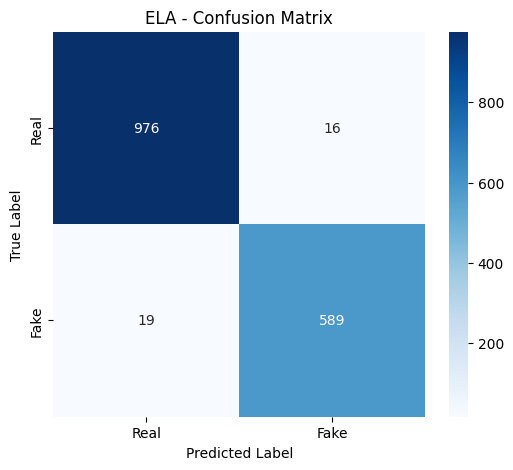


--- Starting Evaluation for SRM ---
Processed 10 batches...
Processed 20 batches...
Processed 30 batches...
Processed 40 batches...
Processed 50 batches...

--- SRM Classification Report ---
              precision    recall  f1-score   support

        Real       1.00      0.88      0.93       928
        Fake       0.85      1.00      0.92       672

    accuracy                           0.93      1600
   macro avg       0.93      0.94      0.93      1600
weighted avg       0.94      0.93      0.93      1600

ROC-AUC Score: 0.9959


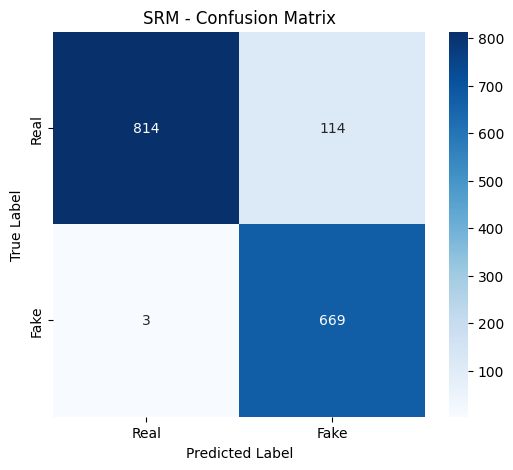

In [12]:
evaluate_model_safely(ela_model, test_dataset, representation_name="ELA")
evaluate_model_safely(srm_model, test_dataset, representation_name="SRM")

Step 6: Grad-CAM Explainability Analysis
Generates Grad-CAM heatmaps from the final convolutional layer to analyze whether the model focuses on facial features (eyes, nose, mouth) or background regions for correct and incorrect prediction

Selected sample image for Grad-CAM: /kaggle/input/datasets/fahimahamed20301393/shom-dataset/Shom/real_vs_fake/real-vs-fake/test/real/16015.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


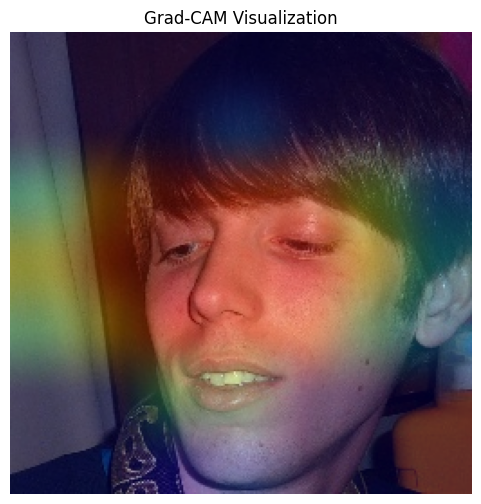

Grad-CAM visualization generated successfully!


In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import tensorflow as tf
import random
import os

# 1. Define the Grad-CAM Heatmap Function
def generate_gradcam_heatmap(model, img_array, last_conv_layer_name="block_16_project"):
    #"""Generate Grad-CAM heatmap to explain model predictions."""
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 2. Automatically pick a random sample image from your already-loaded test directory
test_classes = os.listdir(test_dir)
random_class = random.choice(test_classes)
class_path = os.path.join(test_dir, random_class)
sample_path = os.path.join(class_path, random.choice(os.listdir(class_path)))

print(f"Selected sample image for Grad-CAM: {sample_path}")

# 3. Preprocess the single image for the model
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# 4. Generate the Grad-CAM heatmap using the corrected layer name
heatmap = generate_gradcam_heatmap(rgb_model, img_array, last_conv_layer_name="block_16_project")

# 5. Function to display the heatmap overlaid on the original image
def display_gradcam(img_path, heatmap, alpha=0.4):
    original_img = tf.keras.utils.load_img(img_path)
    original_img = tf.keras.utils.img_to_array(original_img)
    
    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)
    
    # Use Jet colormap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Resize heatmap to match original image dimensions
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((original_img.shape[1], original_img.shape[0]))
    jet_heatmap_arr = tf.keras.utils.img_to_array(jet_heatmap)
    
    # Superimpose the heatmap on the original image
    superimposed_img = jet_heatmap_arr * alpha + original_img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    
    # Plot the final output
    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Visualization")
    plt.axis('off')
    plt.show()

# 6. Display the result!
display_gradcam(sample_path, heatmap)
print("Grad-CAM visualization generated successfully!")

✅ Selected Sample Image File: /kaggle/input/datasets/fahimahamed20301393/shom-dataset/Shom/real_vs_fake/real-vs-fake/valid/fake/W3DVWMWYOI.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_157']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_314']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


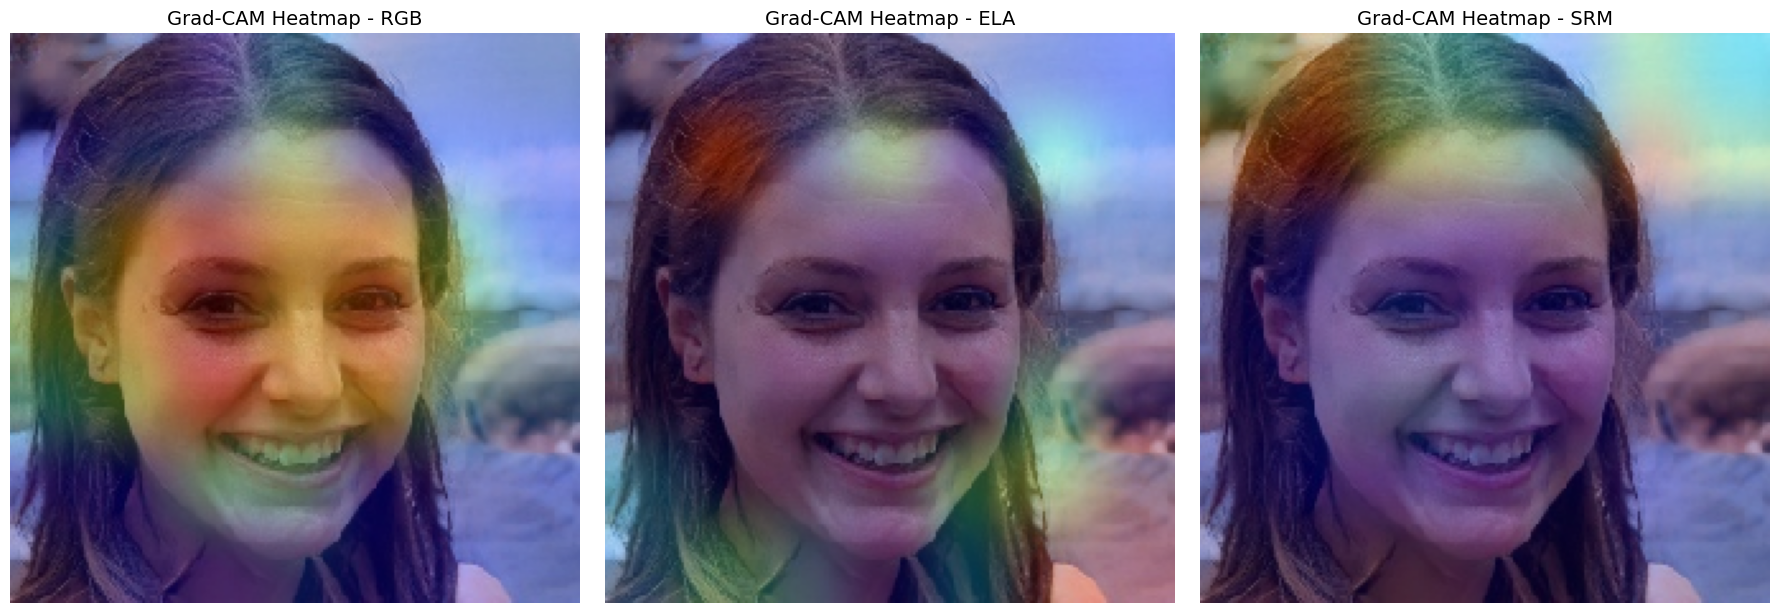

In [14]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


# --- 1. Grad-CAM Heatmap Generation Function ---
def make_gradcam_heatmap(
    img_array, model, last_conv_layer_name, pred_index=None
):
  grad_model = tf.keras.models.Model(
      model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
  )

  with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(img_array)
    if pred_index is None:
      pred_index = tf.argmax(preds[0])
    class_channel = preds[:, pred_index]

  grads = tape.gradient(class_channel, last_conv_layer_output)
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  last_conv_layer_output = last_conv_layer_output[0]
  heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)

  heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
  return heatmap.numpy()


# --- 2. Heatmap Superimpose Function (Warning Fixed) ---
def display_gradcam(img, heatmap, alpha=0.4):
  heatmap = np.uint8(255 * heatmap)
  # Matplotlib deprecation warning fix korar jonno colormaps use kora holo
  jet = plt.colormaps['jet']
  jet_colors = jet(np.arange(256))[:, :3]
  jet_heatmap = jet_colors[heatmap]

  jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
  jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
  jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

  superimposed_img = jet_heatmap * alpha + img
  superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
  return superimposed_img


# --- 3. Test Image Select Kora ---
all_images = glob.glob('/kaggle/input/**/*.jpg', recursive=True)
found_images = [f for f in all_images if os.path.isfile(f)]

if found_images:
  sample_path = found_images[0]
  print(f'✅ Selected Sample Image File: {sample_path}')
else:
  raise ValueError('❌ Kono image file pawa jayni!')

# --- 4. Models & Plotting ---
models = [rgb_model, ela_model, srm_model]
representations = ['RGB', 'ELA', 'SRM']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, rep in enumerate(representations):
  current_model = models[i]

  try:
    # Image load & Preprocess
    img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)

    if rep == 'RGB':
      processed_img = np.expand_dims(img_array, axis=0) / 255.0
      display_img = img_array.astype('uint8')

    elif rep == 'ELA':
      # [NOTE]: Apnar training-er shomoy ELA er kono function thakle ekhane apply hobe
      # jemon: img_array = apply_ela(img_array)
      processed_img = np.expand_dims(img_array, axis=0) / 255.0
      display_img = img_array.astype('uint8')

    elif rep == 'SRM':
      # [NOTE]: Apnar training-er shomoy SRM er kono filter thakle ekhane apply hobe
      # jemon: img_array = apply_srm(img_array)
      processed_img = np.expand_dims(img_array, axis=0) / 255.0
      display_img = img_array.astype('uint8')

    # Generate Heatmap
    heatmap = make_gradcam_heatmap(
        processed_img, current_model, last_conv_layer_name='out_relu'
    )

    # Superimpose Heatmap
    superimposed_img = display_gradcam(display_img, heatmap)

    axes[i].imshow(superimposed_img)
  except Exception as e:
    print(f'Error in {rep}: {e}')
    axes[i].imshow(img_array.astype('uint8'))

  axes[i].set_title(f'Grad-CAM Heatmap - {rep}', fontsize=14)
  axes[i].axis('off')

plt.tight_layout()
plt.savefig('GradCAM_All_Representations_With_Heatmap.png', dpi=300)
plt.show()